In [1]:

import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")
data=pd.read_csv(path + "/netflix_titles.csv")
df=pd.DataFrame(data)
df.head()
df['movie_duration(in minutes)'] = df['duration'].apply(lambda x: int(x.split()[0]) if 'min' in str(x) else None)
df['tv_show_seasons'] = df['duration'].apply(lambda x: int(x.split()[0]) if 'Season' in str(x) else None)
df.drop(columns=['duration'], inplace=True)
df.head()

Using Colab cache for faster access to the 'netflix-shows' dataset.


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,movie_duration(in minutes),tv_show_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0


In [2]:
#  Expand the comma-separated strings in cast, director, country,and listed_in so they can be accurately counted and visualized.
df['cast'] = df['cast'].str.split(',')
df['listed_in'] = df['listed_in'].str.split(',')
df['director'] = df['director'].str.split(',')
df['country'] = df['country'].str.split(',')


df.head()
# Datetime Parsing: Clean the date_added column into a proper datetime object and extract
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_of_week_added'] = df['date_added'].dt.day_name()
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,movie_duration(in minutes),tv_show_seasons,year_added,month_added,day_of_week_added
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],NaN,[United States],2021-09-25,2020,PG-13,[Documentaries],"As her father nears the end of his life, filmm...",90.0,NaN,2021.0,9.0,Saturday
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",[South Africa],2021-09-24,2021,TV-MA,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t...",NaN,2.0,2021.0,9.0,Friday
2,s3,TV Show,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ...",NaN,2021-09-24,2021,TV-MA,"[Crime TV Shows, International TV Shows, TV ...",To protect his family from a powerful drug lor...,NaN,1.0,2021.0,9.0,Friday
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",NaN,1.0,2021.0,9.0,Friday
4,s5,TV Show,Kota Factory,NaN,"[Mayur More, Jitendra Kumar, Ranjan Raj, Al...",[India],2021-09-24,2021,TV-MA,"[International TV Shows, Romantic TV Shows, ...",In a city of coaching centers known to train I...,NaN,2.0,2021.0,9.0,Friday


In [8]:
df.groupby(['year_added', 'type']).size().reset_index(name='count')
df.groupby(['month_added', 'type']).size().reset_index(name='count')
#finding the most popular month for new releases.
print(df['month_added'].value_counts().idxmax())
df.groupby(['cast', 'director']).size().reset_index(name='count').sort_values('count', ascending=False).head(5)

7.0


,cast,director,count
5339,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",Rajiv Chilaka,12
4128,"Prabhas, Rana Daggubati, Anushka Shetty, Taman...",S.S. Rajamouli,4
180,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madh...",Rathindran R Prasad,4
4129,"Prabhas, Rana Daggubati, Anushka Shetty, Taman...",S.S. Rajamouli,3
4571,Sam Kinison,Walter C. Miller,3


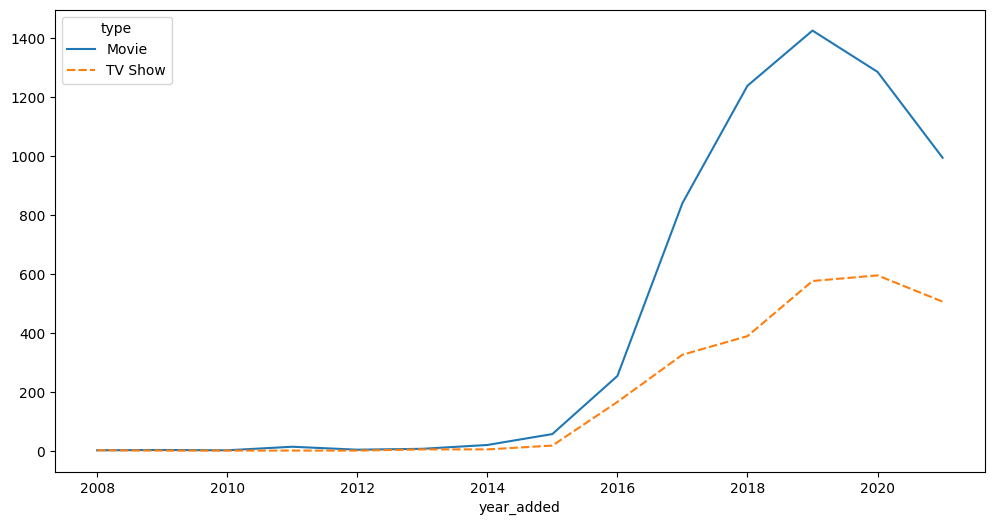

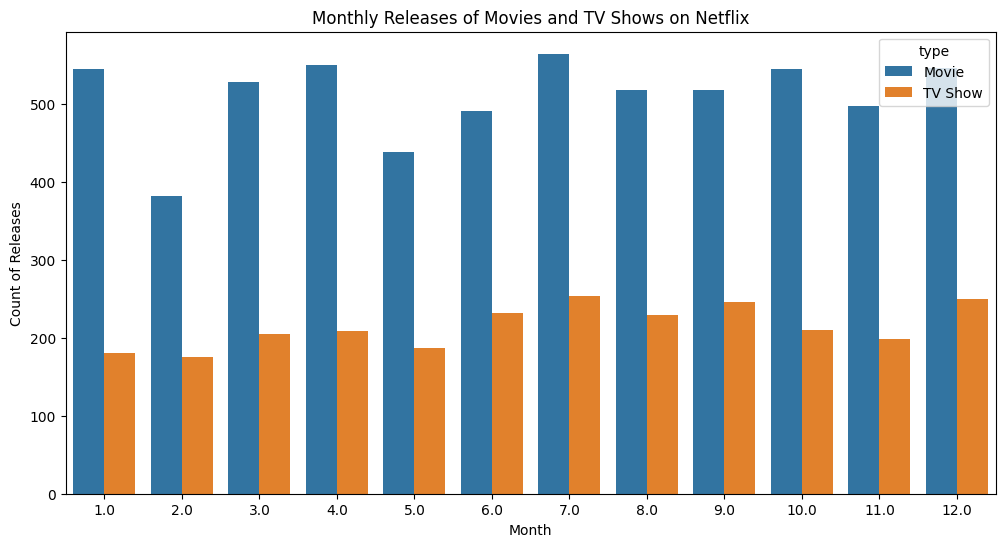

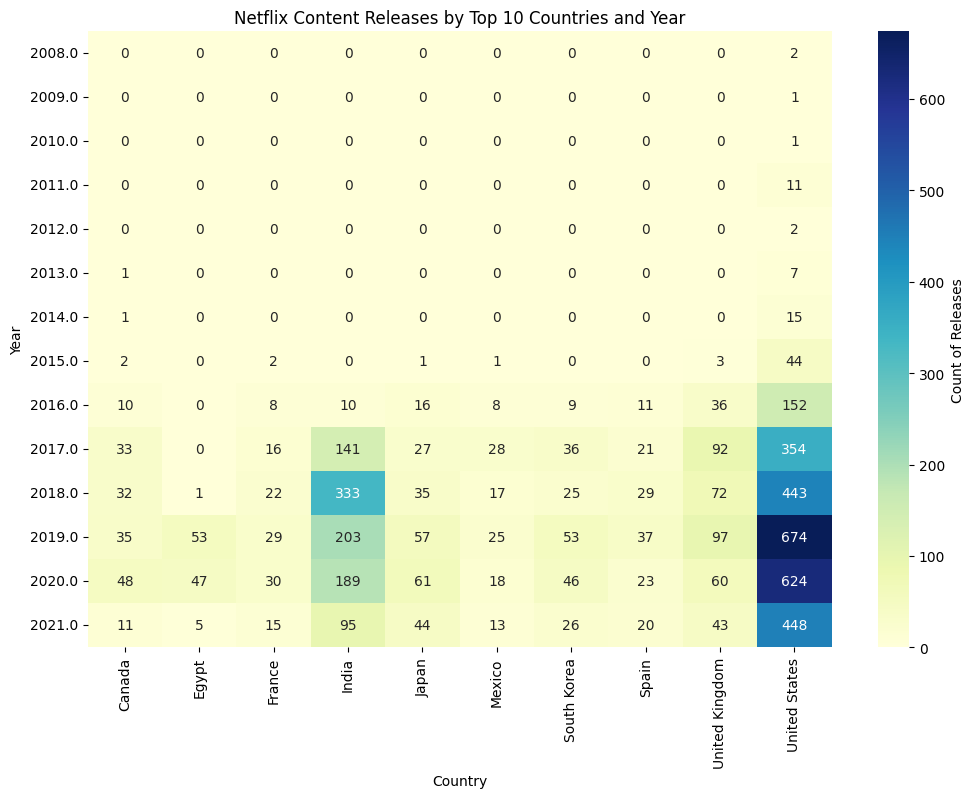

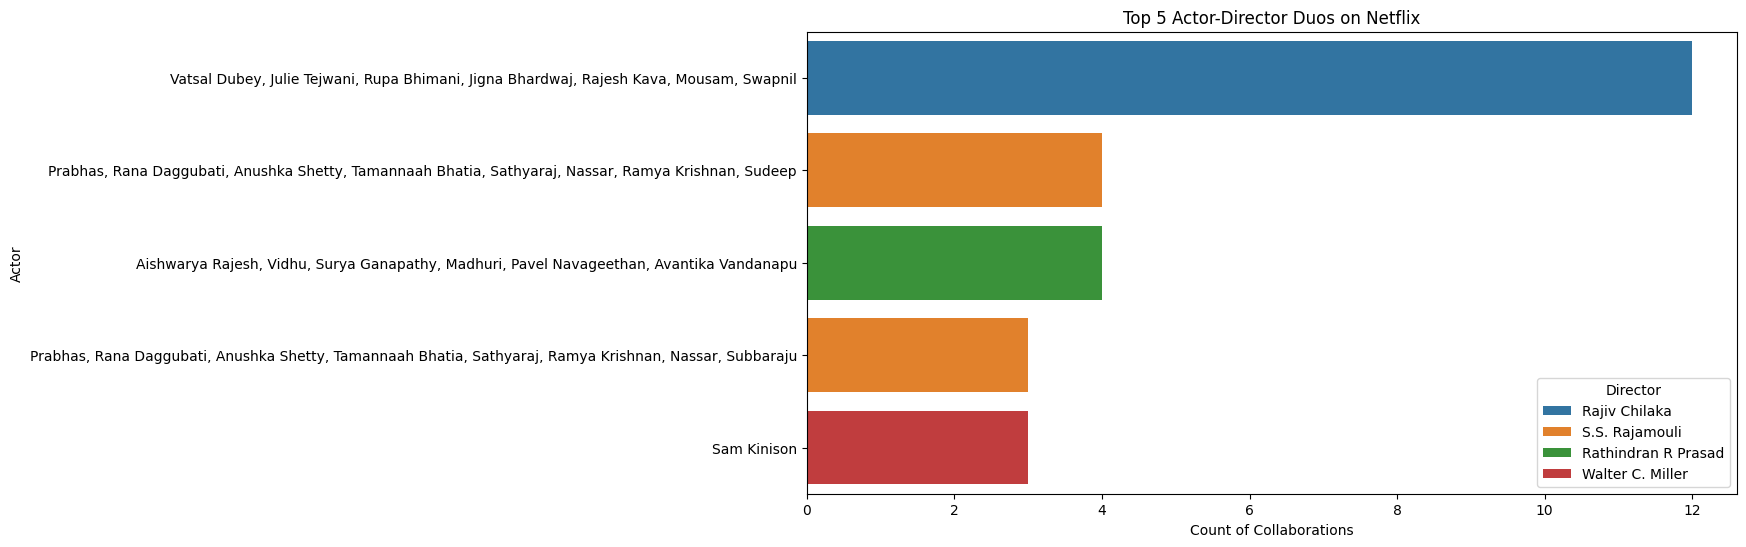

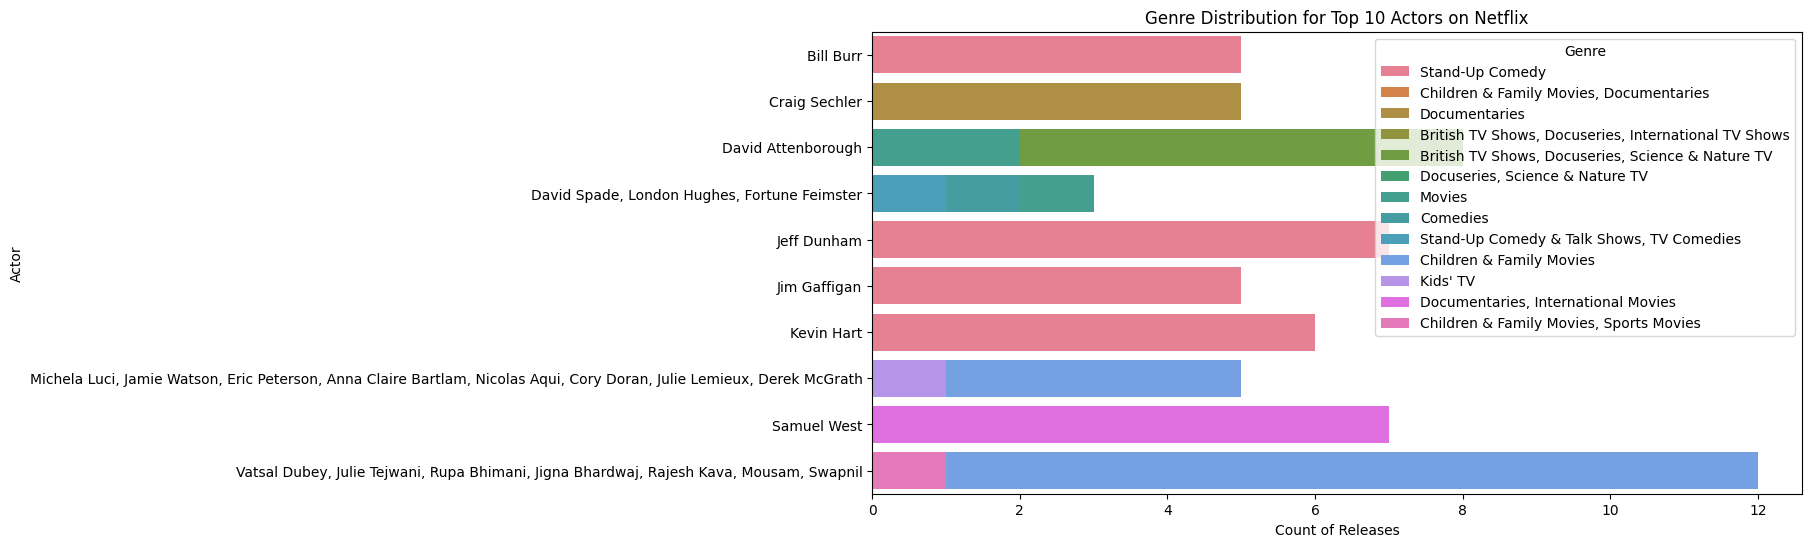

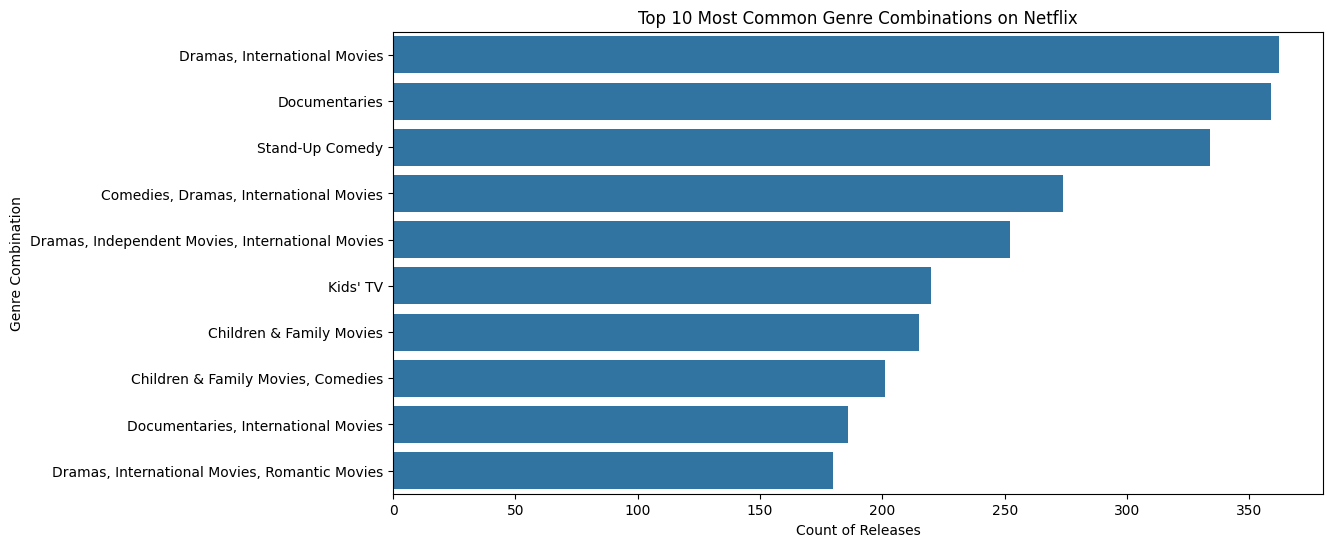

In [4]:
# How has Netflix's focus shifted between Movies and TV Shows over the last  decade?
import matplotlib.pyplot as plt
import seaborn as sns
plot_data = df.groupby(['year_added', 'type']).size().reset_index(name='count')
plot_data = plot_data.pivot(index='year_added', columns='type', values='count').fillna(0)
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data)
# now finding the most popular months for new releases by plotting month numbers on x-axis and count of releases on y-axis plotting barchart for each type of release (Movie or TV Show) for each month.
monthly_data = df.groupby(['month_added', 'type']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_data, x='month_added', y='count', hue='type')
plt.title('Monthly Releases of Movies and TV Shows on Netflix')
plt.xlabel('Month')
plt.ylabel('Count of Releases')
plt.show()
# now plotting the heatmap to know which countries collaborate the most with Netflix for content creation. For this, we will create a pivot table with countries on the x-axis and years on the y-axis, and the count of releases as the values. Then we will plot a heatmap using seaborn for better visualization use better color palette and annotate the heatmap with the count values.
country_data = df.groupby(['country', 'year_added']).size().reset_index(name='count')
country_pivot = country_data.pivot(index='year_added', columns='country', values='count').fillna(0)
top_countries = df['country'].value_counts().nlargest(10).index
filtered_country_data = country_data[country_data['country'].isin(top_countries)]
filtered_country_pivot = filtered_country_data.pivot(index='year_added', columns='country', values='count').fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_country_pivot, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Count of Releases'})
plt.title('Netflix Content Releases by Top 10 Countries and Year')
plt.xlabel('Country')
plt.ylabel('Year')
plt.show()
# now plotting the suitable graph to know the most frequent actor-director duos.
actor_director_data = df.groupby(['cast', 'director']).size().reset_index(name='count').sort_values('count', ascending=False).head(5)
plt.figure(figsize=(12, 6))
sns.barplot(data=actor_director_data, x='count', y='cast', hue='director')
plt.title('Top 5 Actor-Director Duos on Netflix')
plt.xlabel('Count of Collaborations')
plt.ylabel('Actor')
plt.legend(title='Director')
plt.show()
# now plotting the genre distribution for the top 10 actors.
top_10_actors = df['cast'].value_counts().nlargest(10).index
genre_data = df[df['cast'].isin(top_10_actors)].groupby(['cast', 'listed_in']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_data, x='count', y='cast', hue='listed_in', dodge=False)
plt.title('Genre Distribution for Top 10 Actors on Netflix')
plt.xlabel('Count of Releases')
plt.ylabel('Actor')
plt.legend(title='Genre')
plt.show()
# now plotting to get information about most common combinations of genres in Netflix content.
df['genre_combination'] = df['listed_in'].apply(lambda x: ', '.join(sorted(x.split(', '))) if pd.notnull(x) else '')
genre_combination_data = df.groupby('genre_combination').size().reset_index(name='count').sort_values('count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_combination_data, x='count', y='genre_combination')
plt.title('Top 10 Most Common Genre Combinations on Netflix')
plt.xlabel('Count of Releases')
plt.ylabel('Genre Combination')
plt.show()